In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.transforms import v2

In [2]:
train_dir = "/home/skandan-c-y/PycharmProjects/PyTorch/data/intel-image-classification/seg_train/seg_train"
test_dir = "/home/skandan-c-y/PycharmProjects/PyTorch/data/intel-image-classification/seg_test/seg_test"
pred_dir = "/home/skandan-c-y/PycharmProjects/PyTorch/data/intel-image-classification/seg_pred"

import os
from PIL import Image

def inspect_image(path):
    for root, _, files in os.walk(path):
        for file in files:
            if file.lower().endswith(('.png', 'jpg', 'jpeg')):
                img_path = os.path.join(root, file)
                with Image.open(img_path) as img:
                    return img.size
    raise FileNotFoundError(f"Valid image doesn't exist in the folder {path}")

train_img_size = inspect_image(train_dir)
test_img_size = inspect_image(test_dir)

print(f"Training image size: {train_img_size}")
print(f"Test image size: {test_img_size}")

Training image size: (150, 150)
Test image size: (150, 150)


## Data transforms

In [3]:
# define the transforms

torch.manual_seed(5)

train_transform = v2.Compose([
    v2.Resize((150,150)),
    v2.RandomHorizontalFlip(),
    v2.RandomRotation(10),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=(0.485,0.456,0.406),
        std=(0.229,0.224,0.225)
    )
])

test_transform = v2.Compose([
    v2.Resize((150,150)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=(0.485,0.456,0.406),
        std=(0.229,0.224,0.225)
    )
])

display_transform = v2.Compose([
    v2.Resize((150, 150))
])

## Loading dataset and data loaders

In [4]:
from torchvision.datasets import ImageFolder

training_dataset = ImageFolder(root=train_dir, transform=train_transform)
testing_dataset = ImageFolder(root=test_dir, transform=test_transform)

training_loader = DataLoader(dataset=training_dataset, batch_size=64, shuffle=True, num_workers=6)
testing_loader = DataLoader(dataset=testing_dataset, batch_size=64, num_workers=6)

## Offload the work to GPU (if available)

In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


## Defining our NN models
We shall be testing out:
1. Normal CNN (baseline) - done
2. \+ BatchNorm
3. \+ Dropout
4. \+ Data augmentation

In [6]:
import math

def give_size(existing, padding, kernel, stride):
    print(math.floor((existing + 2*padding - kernel)/stride) + 1)

give_size(74, 1, 3, 1)
give_size(36, 0, 3, 2)

74
17


### 1. Baseline CNN

In [7]:
# Normal CNN

class CNN_baseline(nn.Module):
    def __init__(self):
        super().__init__()

        self.feature_extraction = nn.Sequential(
            nn.Conv2d(                                              # (150+2(1)-3)/1 + 1 = 148; (3, 150, 150) -> (32, 150, 150)
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),                  # (148+2(0)-3)/2 + 1 = 74;  (32, 150, 150) -> (32, 74, 74)
            nn.Conv2d(                                              # (74+2(1)-3)/1 + 1 = 70;   (32, 74, 74) -> (64, 74, 74)
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),                  # (74+2(0)-3)/2 + 1 = 36; (64, 74, 74) -> (64, 36, 36)
            nn.Conv2d(                                              # (36+2(1)-3)/1 + 1 = 36;   (64, 36, 36) -> (128, 36, 36)
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),                  # (36+2(0)-3)/2 + 1 = 17; (128, 36, 36) -> (128, 17, 17)
        )

        self.clf = nn.Sequential(
            nn.Flatten(),                                           # 128*17*17 = 36992,
            nn.Linear(128*17*17, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 6)
        )

    def forward(self, x):
        x = self.feature_extraction(x)
        x = self.clf(x)
        return x

base_cnn = CNN_baseline().to(device)

In [8]:
# total number of trainable parameters
num_params = sum(
    p.numel()
    for p in base_cnn.parameters()
    if p.requires_grad
)

print(f"{num_params:,}")

19,100,102


In [9]:
# loss, optimizer

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    params=base_cnn.parameters(),
    lr=1e-3
)

In [10]:
# metrics storage

training_acc_1 = []
training_loss_1 = []
validation_acc_1 = []
validation_loss_1 = []

In [11]:
# training function

def train_one_epoch1(model, loader):
    model.train()

    running_loss = 0
    correct  = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        predictions = outputs.argmax(1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy

In [12]:
# validation function

def validation(model, loader):
    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)

            loss = criterion(outputs, labels)
            running_loss += loss.item()
            predictions = outputs.argmax(1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy

In [13]:
# training loop

epochs = 15

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch1(
        base_cnn, training_loader
    )
    val_loss, val_acc = validation(
        base_cnn, testing_loader
    )

    training_loss_1.append(train_loss)
    training_acc_1.append(train_acc)
    validation_loss_1.append(val_loss)
    validation_acc_1.append(val_acc)

    print(
        f"Epoch {epoch+1:2d} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.4f}"
    )

Epoch  1 | Train Loss 0.9036 | Train Acc 0.6566 | Val Loss 0.6278 | Val Acc 0.7800
Epoch  2 | Train Loss 0.5743 | Train Acc 0.7933 | Val Loss 0.5120 | Val Acc 0.8263
Epoch  3 | Train Loss 0.4786 | Train Acc 0.8290 | Val Loss 0.6020 | Val Acc 0.7873
Epoch  4 | Train Loss 0.4311 | Train Acc 0.8444 | Val Loss 0.4472 | Val Acc 0.8420
Epoch  5 | Train Loss 0.3814 | Train Acc 0.8634 | Val Loss 0.4320 | Val Acc 0.8510
Epoch  6 | Train Loss 0.3374 | Train Acc 0.8802 | Val Loss 0.4198 | Val Acc 0.8543
Epoch  7 | Train Loss 0.3142 | Train Acc 0.8903 | Val Loss 0.4435 | Val Acc 0.8613
Epoch  8 | Train Loss 0.2821 | Train Acc 0.8977 | Val Loss 0.4711 | Val Acc 0.8527
Epoch  9 | Train Loss 0.2478 | Train Acc 0.9105 | Val Loss 0.5868 | Val Acc 0.8213
Epoch 10 | Train Loss 0.2248 | Train Acc 0.9173 | Val Loss 0.4516 | Val Acc 0.8540
Epoch 11 | Train Loss 0.2030 | Train Acc 0.9270 | Val Loss 0.5341 | Val Acc 0.8443
Epoch 12 | Train Loss 0.1899 | Train Acc 0.9323 | Val Loss 0.5230 | Val Acc 0.8420
Epoc

### 2. CNN + BatchNorm

In [18]:
# CNN + BatchNorm

class CNN_BN(nn.Module):
    def __init__(self):
        super().__init__()

        self.feature_extraction = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        self.clf = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 17 * 17, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 6)
        )

    def forward(self, x):
        x = self.feature_extraction(x)
        x = self.clf(x)
        return x

bn_cnn = CNN_BN().to(device)
print(f"Trainable params: {sum(p.numel() for p in bn_cnn.parameters() if p.requires_grad):,}")

Trainable params: 19,100,550


In [19]:
# loss, optimizer for BN model

criterion_bn = nn.CrossEntropyLoss()

optimizer_bn = optim.Adam(
    params=bn_cnn.parameters(),
    lr=1e-3
)

In [20]:
# metrics storage for BN model

training_acc_2 = []
training_loss_2 = []
validation_acc_2 = []
validation_loss_2 = []

In [21]:
# training function for BN model

def train_one_epoch2(model, loader):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer_bn.zero_grad()

        outputs = model(images)
        loss = criterion_bn(outputs, labels)
        loss.backward()
        optimizer_bn.step()

        running_loss += loss.item()
        predictions = outputs.argmax(1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy

In [22]:
# training loop for BN model

epochs = 15

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch2(bn_cnn, training_loader)
    val_loss, val_acc = validation(bn_cnn, testing_loader)

    training_loss_2.append(train_loss)
    training_acc_2.append(train_acc)
    validation_loss_2.append(val_loss)
    validation_acc_2.append(val_acc)

    print(
        f"Epoch {epoch+1:2d} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.4f}"
    )

Epoch  1 | Train Loss 1.2091 | Train Acc 0.6114 | Val Loss 0.8495 | Val Acc 0.6793
Epoch  2 | Train Loss 0.6500 | Train Acc 0.7585 | Val Loss 0.5582 | Val Acc 0.8003
Epoch  3 | Train Loss 0.5410 | Train Acc 0.8040 | Val Loss 0.9197 | Val Acc 0.6677
Epoch  4 | Train Loss 0.4827 | Train Acc 0.8246 | Val Loss 0.4889 | Val Acc 0.8300
Epoch  5 | Train Loss 0.4531 | Train Acc 0.8345 | Val Loss 0.5932 | Val Acc 0.7907
Epoch  6 | Train Loss 0.4274 | Train Acc 0.8438 | Val Loss 0.4877 | Val Acc 0.8287
Epoch  7 | Train Loss 0.3981 | Train Acc 0.8539 | Val Loss 0.3989 | Val Acc 0.8597
Epoch  8 | Train Loss 0.3728 | Train Acc 0.8629 | Val Loss 0.4413 | Val Acc 0.8507
Epoch  9 | Train Loss 0.3600 | Train Acc 0.8717 | Val Loss 0.4822 | Val Acc 0.8253
Epoch 10 | Train Loss 0.3425 | Train Acc 0.8759 | Val Loss 0.4760 | Val Acc 0.8510
Epoch 11 | Train Loss 0.3261 | Train Acc 0.8809 | Val Loss 0.4156 | Val Acc 0.8650
Epoch 12 | Train Loss 0.3046 | Train Acc 0.8915 | Val Loss 0.7560 | Val Acc 0.7637
Epoc

### 3. CNN + Dropout

In [23]:
# CNN + Dropout

class CNN_Dropout(nn.Module):
    def __init__(self, dropout_p=0.4):
        super().__init__()

        self.feature_extraction = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        self.clf = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 17 * 17, 512),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(128, 6)
        )

    def forward(self, x):
        x = self.feature_extraction(x)
        x = self.clf(x)
        return x

drop_cnn = CNN_Dropout(dropout_p=0.4).to(device)
print(f"Trainable params: {sum(p.numel() for p in drop_cnn.parameters() if p.requires_grad):,}")

Trainable params: 19,100,102


In [24]:
# loss, optimizer for Dropout model

criterion_drop = nn.CrossEntropyLoss()

optimizer_drop = optim.Adam(
    params=drop_cnn.parameters(),
    lr=1e-3
)

In [25]:
# metrics storage for Dropout model

training_acc_3 = []
training_loss_3 = []
validation_acc_3 = []
validation_loss_3 = []

In [26]:
# training function for Dropout model

def train_one_epoch3(model, loader):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer_drop.zero_grad()

        outputs = model(images)
        loss = criterion_drop(outputs, labels)
        loss.backward()
        optimizer_drop.step()

        running_loss += loss.item()
        predictions = outputs.argmax(1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy

In [27]:
# training loop for Dropout model

epochs = 15

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch3(drop_cnn, training_loader)
    val_loss, val_acc = validation(drop_cnn, testing_loader)

    training_loss_3.append(train_loss)
    training_acc_3.append(train_acc)
    validation_loss_3.append(val_loss)
    validation_acc_3.append(val_acc)

    print(
        f"Epoch {epoch+1:2d} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.4f}"
    )

Epoch  1 | Train Loss 1.0747 | Train Acc 0.5863 | Val Loss 0.6971 | Val Acc 0.7567
Epoch  2 | Train Loss 0.7195 | Train Acc 0.7465 | Val Loss 0.6316 | Val Acc 0.7717
Epoch  3 | Train Loss 0.5756 | Train Acc 0.7974 | Val Loss 0.5049 | Val Acc 0.8143
Epoch  4 | Train Loss 0.5170 | Train Acc 0.8166 | Val Loss 0.4688 | Val Acc 0.8340
Epoch  5 | Train Loss 0.4640 | Train Acc 0.8376 | Val Loss 0.4299 | Val Acc 0.8493
Epoch  6 | Train Loss 0.4396 | Train Acc 0.8477 | Val Loss 0.4356 | Val Acc 0.8507
Epoch  7 | Train Loss 0.4135 | Train Acc 0.8591 | Val Loss 0.4421 | Val Acc 0.8493
Epoch  8 | Train Loss 0.3906 | Train Acc 0.8648 | Val Loss 0.4208 | Val Acc 0.8607
Epoch  9 | Train Loss 0.3637 | Train Acc 0.8723 | Val Loss 0.4451 | Val Acc 0.8507
Epoch 10 | Train Loss 0.3307 | Train Acc 0.8832 | Val Loss 0.4193 | Val Acc 0.8637
Epoch 11 | Train Loss 0.3223 | Train Acc 0.8861 | Val Loss 0.4656 | Val Acc 0.8493
Epoch 12 | Train Loss 0.3080 | Train Acc 0.8891 | Val Loss 0.3888 | Val Acc 0.8693
Epoc

### 4. CNN + BatchNorm + Dropout + Data Augmentation

Data augmentation is already applied via `train_transform` (RandomHorizontalFlip + RandomRotation).  
This model combines all regularisation techniques: BatchNorm in the conv blocks and Dropout in the classifier.

In [28]:
# CNN + BatchNorm + Dropout + Data Augmentation

class CNN_Full(nn.Module):
    """Combines BatchNorm (after each conv), Dropout (in classifier),
    and data augmentation (baked into train_transform)."""

    def __init__(self, dropout_p=0.4):
        super().__init__()

        self.feature_extraction = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        self.clf = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 17 * 17, 512),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(128, 6)
        )

    def forward(self, x):
        x = self.feature_extraction(x)
        x = self.clf(x)
        return x

full_cnn = CNN_Full(dropout_p=0.4).to(device)
print(f"Trainable params: {sum(p.numel() for p in full_cnn.parameters() if p.requires_grad):,}")

Trainable params: 19,100,550


In [29]:
# loss, optimizer for Full model

criterion_full = nn.CrossEntropyLoss()

optimizer_full = optim.Adam(
    params=full_cnn.parameters(),
    lr=1e-3
)

In [30]:
# metrics storage for Full model

training_acc_4 = []
training_loss_4 = []
validation_acc_4 = []
validation_loss_4 = []

In [31]:
# training function for Full model

def train_one_epoch4(model, loader):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer_full.zero_grad()

        outputs = model(images)
        loss = criterion_full(outputs, labels)
        loss.backward()
        optimizer_full.step()

        running_loss += loss.item()
        predictions = outputs.argmax(1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy

In [32]:
# training loop for Full model

epochs = 15

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch4(full_cnn, training_loader)
    val_loss, val_acc = validation(full_cnn, testing_loader)

    training_loss_4.append(train_loss)
    training_acc_4.append(train_acc)
    validation_loss_4.append(val_loss)
    validation_acc_4.append(val_acc)

    print(
        f"Epoch {epoch+1:2d} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.4f}"
    )

Epoch  1 | Train Loss 1.3906 | Train Acc 0.5296 | Val Loss 0.8383 | Val Acc 0.6890
Epoch  2 | Train Loss 0.8731 | Train Acc 0.6734 | Val Loss 0.6994 | Val Acc 0.7407
Epoch  3 | Train Loss 0.7534 | Train Acc 0.7299 | Val Loss 0.6695 | Val Acc 0.7680
Epoch  4 | Train Loss 0.6838 | Train Acc 0.7577 | Val Loss 0.6875 | Val Acc 0.7400
Epoch  5 | Train Loss 0.6360 | Train Acc 0.7792 | Val Loss 0.5550 | Val Acc 0.8013
Epoch  6 | Train Loss 0.5973 | Train Acc 0.7938 | Val Loss 0.4861 | Val Acc 0.8397
Epoch  7 | Train Loss 0.5570 | Train Acc 0.8079 | Val Loss 0.5068 | Val Acc 0.8247
Epoch  8 | Train Loss 0.5479 | Train Acc 0.8070 | Val Loss 0.5570 | Val Acc 0.7953
Epoch  9 | Train Loss 0.5459 | Train Acc 0.8082 | Val Loss 0.4655 | Val Acc 0.8317
Epoch 10 | Train Loss 0.5254 | Train Acc 0.8211 | Val Loss 0.5211 | Val Acc 0.8203
Epoch 11 | Train Loss 0.5006 | Train Acc 0.8281 | Val Loss 0.4371 | Val Acc 0.8480
Epoch 12 | Train Loss 0.4975 | Train Acc 0.8307 | Val Loss 0.4620 | Val Acc 0.8390
Epoc

## Comparison Plots (all 4 models)

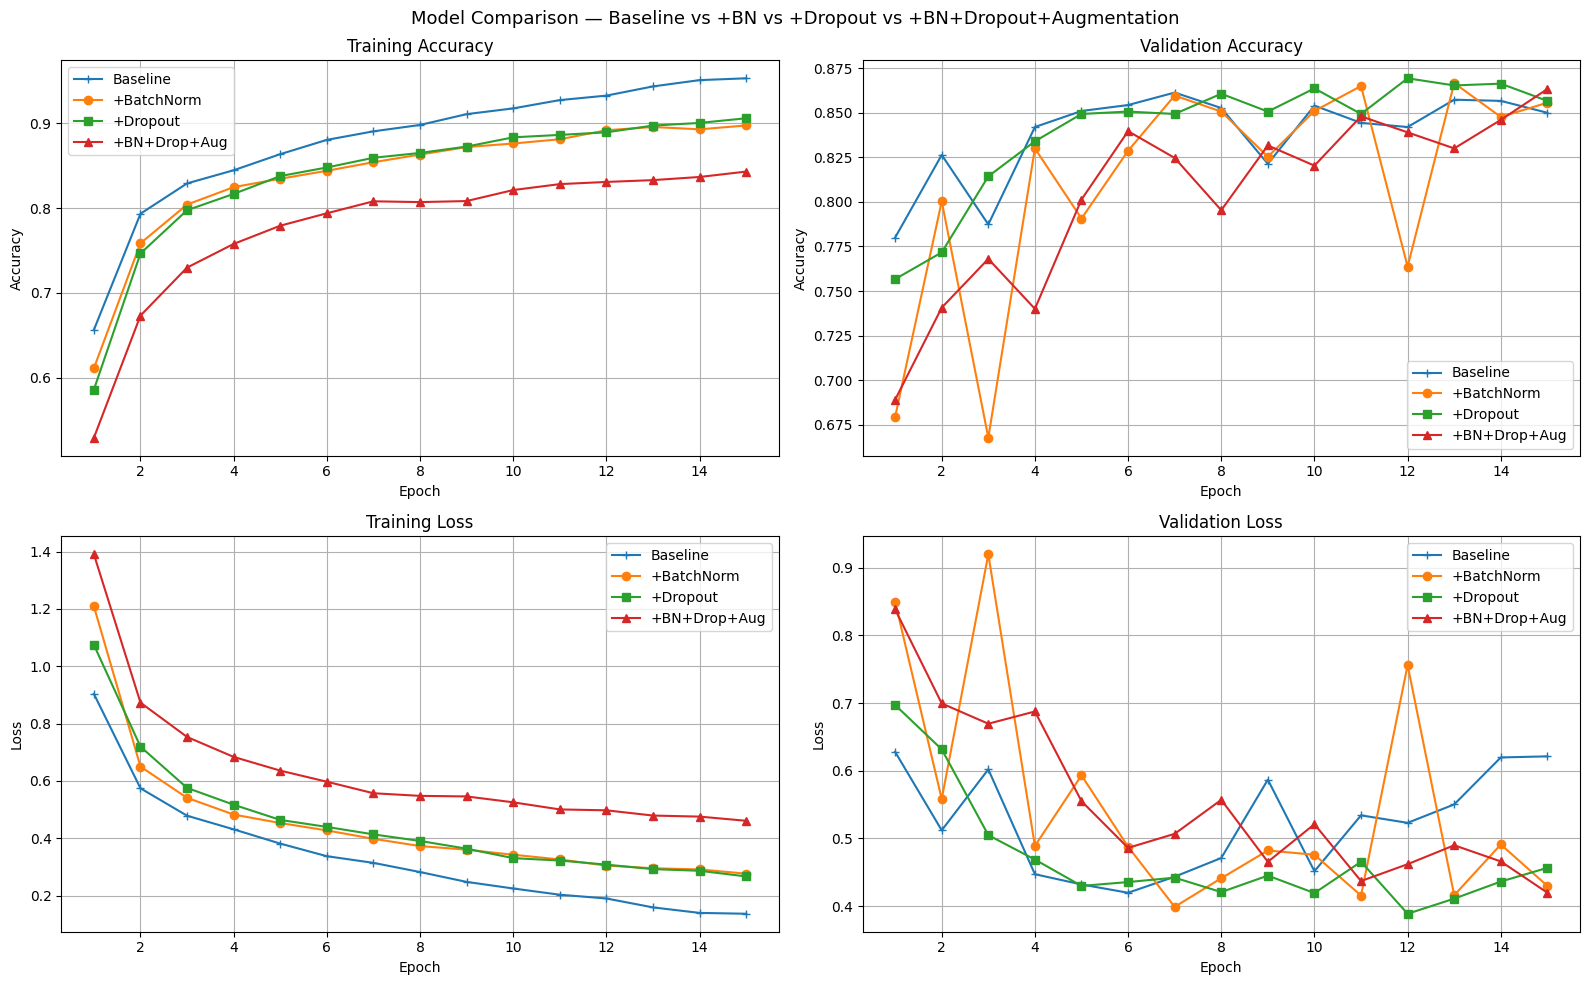

In [33]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Model Comparison — Baseline vs +BN vs +Dropout vs +BN+Dropout+Augmentation", fontsize=13)

epochs_range = range(1, len(training_acc_1) + 1)

# Training Accuracy
ax = axes[0, 0]
ax.plot(epochs_range, training_acc_1, marker='+', label='Baseline')
ax.plot(epochs_range, training_acc_2, marker='o', label='+BatchNorm')
ax.plot(epochs_range, training_acc_3, marker='s', label='+Dropout')
ax.plot(epochs_range, training_acc_4, marker='^', label='+BN+Drop+Aug')
ax.set_title('Training Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True)

# Validation Accuracy
ax = axes[0, 1]
ax.plot(epochs_range, validation_acc_1, marker='+', label='Baseline')
ax.plot(epochs_range, validation_acc_2, marker='o', label='+BatchNorm')
ax.plot(epochs_range, validation_acc_3, marker='s', label='+Dropout')
ax.plot(epochs_range, validation_acc_4, marker='^', label='+BN+Drop+Aug')
ax.set_title('Validation Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True)

# Training Loss
ax = axes[1, 0]
ax.plot(epochs_range, training_loss_1, marker='+', label='Baseline')
ax.plot(epochs_range, training_loss_2, marker='o', label='+BatchNorm')
ax.plot(epochs_range, training_loss_3, marker='s', label='+Dropout')
ax.plot(epochs_range, training_loss_4, marker='^', label='+BN+Drop+Aug')
ax.set_title('Training Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True)

# Validation Loss
ax = axes[1, 1]
ax.plot(epochs_range, validation_loss_1, marker='+', label='Baseline')
ax.plot(epochs_range, validation_loss_2, marker='o', label='+BatchNorm')
ax.plot(epochs_range, validation_loss_3, marker='s', label='+Dropout')
ax.plot(epochs_range, validation_loss_4, marker='^', label='+BN+Drop+Aug')
ax.set_title('Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

In [34]:
# Final summary — best validation accuracy for each model

models_summary = [
    ('Baseline CNN',                  max(validation_acc_1)),
    ('CNN + BatchNorm',               max(validation_acc_2)),
    ('CNN + Dropout',                 max(validation_acc_3)),
    ('CNN + BN + Dropout + Aug',      max(validation_acc_4)),
]

print(f"{'Model':<35} {'Best Val Acc':>12}")
print("-" * 50)
for name, acc in models_summary:
    print(f"{name:<35} {acc:>12.4f}")

Model                               Best Val Acc
--------------------------------------------------
Baseline CNN                              0.8613
CNN + BatchNorm                           0.8667
CNN + Dropout                             0.8693
CNN + BN + Dropout + Aug                  0.8633
